##### EPMT Data "Cleanup" - Next Idea No. "11" (More data - 100k+ rows)

Following up from EPMTDataCleanup_Next7.ipynb<br>

Trying each category individually:
* SLURM_JOB_ACCOUNT

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import ast
from datetime import datetime

%matplotlib inline 

# Suggested by Gemini -- "Makes your plots look a bit more modern/clean"
sns.set_theme(style="whitegrid")

# Load some data and revisit what we have so far

In [3]:
import glob
import os

data_path = 'epmt_data_cleaned_20260326_074338.csv'

df = pd.read_csv(data_path)

In [4]:
df.columns.tolist()

['cpu_time',
 'SLURM_JOB_ACCOUNT',
 'exp_component',
 'exp_name',
 'exp_time',
 'exp_platform',
 'exp_target',
 'exp_seg_months']

In [5]:
len(df)

106447

## Pre-Processing: One-hot encoding
* Including one-hot encoding (from categorial to numerical) to all data
* Specialized reduction of categories (Example: reducing the number of exp_component cateogories)
* I'm not standardizing or normalizing data yet.

In [6]:
from sklearn.preprocessing import OneHotEncoder

In [7]:
feature_cols = ['SLURM_JOB_ACCOUNT']
df[feature_cols].head()

,SLURM_JOB_ACCOUNT
0,gfdl_m
1,gfdl_m
2,gfdl_w
3,gfdl_m
4,gfdl_m


In [8]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].head()

,cpu_time,exp_time,exp_seg_months
0,1.297620e+09,10101,12
1,1.527381e+09,10101,12
2,3.506743e+08,19980101,12
3,6.541279e+08,10101,12
4,5.257977e+08,10101,12


In [9]:
df = df.drop(columns=['exp_time', 'exp_seg_months', 'exp_component', 'exp_name', 'exp_target', 'exp_platform'])
df.head()

,cpu_time,SLURM_JOB_ACCOUNT
0,1.297620e+09,gfdl_m
1,1.527381e+09,gfdl_m
2,3.506743e+08,gfdl_w
3,6.541279e+08,gfdl_m
4,5.257977e+08,gfdl_m


In [10]:
ohe = OneHotEncoder(sparse_output=False)
ohe_data = ohe.fit_transform(df[feature_cols])
ohe_cols = ohe.get_feature_names_out(feature_cols)
df_categorical = pd.DataFrame(ohe_data, columns=ohe_cols)
df_categorical.head()

,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,SLURM_JOB_ACCOUNT_gfdl_m,SLURM_JOB_ACCOUNT_gfdl_o,SLURM_JOB_ACCOUNT_gfdl_sd,SLURM_JOB_ACCOUNT_gfdl_w
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [11]:
df = pd.concat([df, df_categorical], axis=1)
df.head()

,cpu_time,SLURM_JOB_ACCOUNT,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,SLURM_JOB_ACCOUNT_gfdl_m,SLURM_JOB_ACCOUNT_gfdl_o,SLURM_JOB_ACCOUNT_gfdl_sd,SLURM_JOB_ACCOUNT_gfdl_w
0,1.297620e+09,gfdl_m,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.527381e+09,gfdl_m,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.506743e+08,gfdl_w,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,6.541279e+08,gfdl_m,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.257977e+08,gfdl_m,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


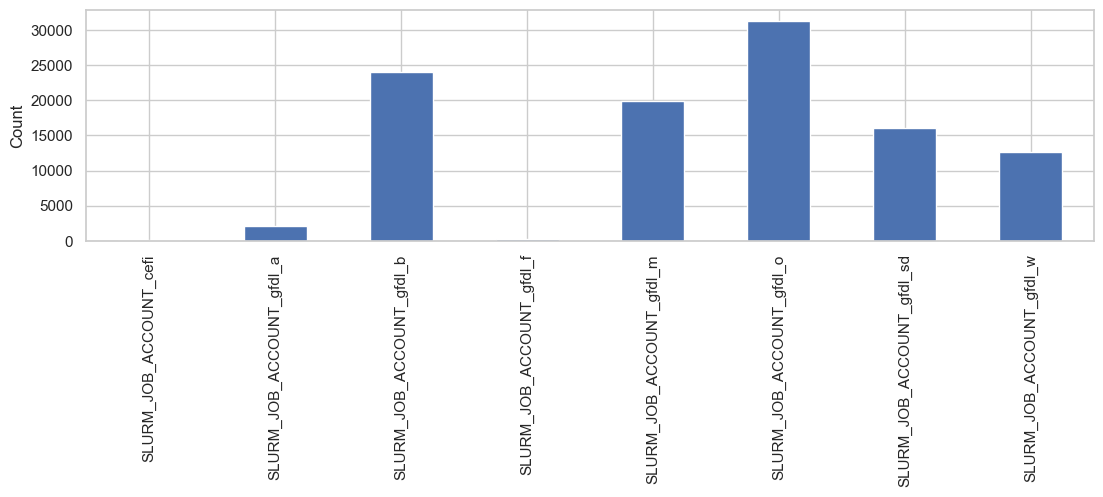

In [12]:
def plot_one_category(df_categorical, single_category):
    startswith = f"{single_category}_"
    cols = [c for c in df_categorical.columns if c.startswith(startswith)]
    df_categorical[cols].sum().plot(kind='bar', figsize=(13,3))
    plt.ylabel('Count')
    plt.show()
    
plot_one_category(df, "SLURM_JOB_ACCOUNT")
df = df.drop(columns=['SLURM_JOB_ACCOUNT'])

## Split Data for Train, Validate, Final Test
* Work with training and validation data first.
* Save the final testing data for later.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.model_selection import GridSearchCV

In [14]:
target = 'cpu_time'
X = df.drop(columns=[target])
y = df[target]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

## Looking at Correlations

In [15]:
df.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time                     1.000000
SLURM_JOB_ACCOUNT_gfdl_b     0.090915
SLURM_JOB_ACCOUNT_gfdl_sd    0.034755
SLURM_JOB_ACCOUNT_cefi       0.007490
SLURM_JOB_ACCOUNT_gfdl_a     0.005541
SLURM_JOB_ACCOUNT_gfdl_m    -0.005325
SLURM_JOB_ACCOUNT_gfdl_f    -0.006185
SLURM_JOB_ACCOUNT_gfdl_w    -0.009063
SLURM_JOB_ACCOUNT_gfdl_o    -0.101322
Name: cpu_time, dtype: float64

### Linear Regression Model

In [16]:
lr_model = make_pipeline(
    LinearRegression()
)

lr_model.fit(X_train, y_train)

lr_val_pred = lr_model.predict(X_val)
lr_mse = mean_squared_error(y_val, lr_val_pred)
lr_r2 = r2_score(y_val, lr_val_pred)

print(f"Mean Squared Error: {lr_mse:.2f}")
print(f"R-squared Score: {lr_r2:.2f}")

Mean Squared Error: 3099468515130805248.00
R-squared Score: 0.02


### MLP

In [17]:
mlp_model = make_pipeline(
    MLPRegressor(hidden_layer_sizes=(20, 20), max_iter=5000, random_state=42)
)

mlp_model.fit(X_train, y_train)

mlp_val_pred = mlp_model.predict(X_val)
mlp_mse = mean_squared_error(y_val, mlp_val_pred)
mlp_r2 = r2_score(y_val, mlp_val_pred)

print(f"Mean Squared Error: {mlp_mse:.2f}")
print(f"R-squared Score: {mlp_r2:.2f}")

Mean Squared Error: 3099979034228556288.00
R-squared Score: 0.02


### Decision Tree

In [18]:
dtree_model = make_pipeline(
    DecisionTreeRegressor(max_depth=15, min_samples_split=5)
)

dtree_model.fit(X_train, y_train)

dtree_val_pred = dtree_model.predict(X_val)
dtree_mse = mean_squared_error(y_val, dtree_val_pred)
dtree_r2 = r2_score(y_val, dtree_val_pred)

print(f"Mean Squared Error: {dtree_mse:.2f}")
print(f"R-squared Score: {dtree_r2:.2f}")

Mean Squared Error: 3099468515130805248.00
R-squared Score: 0.02


## Bagging vs Boosting
* Multiple models independent of eachother, average voting
* Multiple models trained sequentially, weighted voting

https://www.geeksforgeeks.org/machine-learning/bagging-vs-boosting-in-machine-learning/

In [19]:
rf_model = RandomForestRegressor(n_estimators=10, max_depth=15, random_state=42)

rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_val_pred)
rf_r2 = r2_score(y_val, rf_val_pred)

print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R-squared Score: {rf_r2:.2f}")

Mean Squared Error: 3099595465033357312.00
R-squared Score: 0.02


In [20]:
gb_model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, max_depth=10, random_state=42)
gb_model.fit(X_train, y_train)

gb_val_pred = gb_model.predict(X_val)
gb_mse = mean_squared_error(y_val, gb_val_pred)
gb_r2 = r2_score(y_val, gb_val_pred)

print(f"Mean Squared Error: {gb_mse:.2f}")
print(f"R-squared Score: {gb_r2:.2f}")

Mean Squared Error: 3099516948625815040.00
R-squared Score: 0.02


In [21]:
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor(estimators=[
    ('rf', rf_model), 
    #('dtree', dtree_model), 
    #('lr', lr_model),
    ('gb', gb_model),
    #('mlp', mlp_model)
])
ensemble.fit(X_train, y_train)
predictions = ensemble.predict(X_val)

mse = mean_squared_error(y_val, predictions)
r2 = r2_score(y_val, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 3099533417414497792.0000
R-squared Score: 0.02


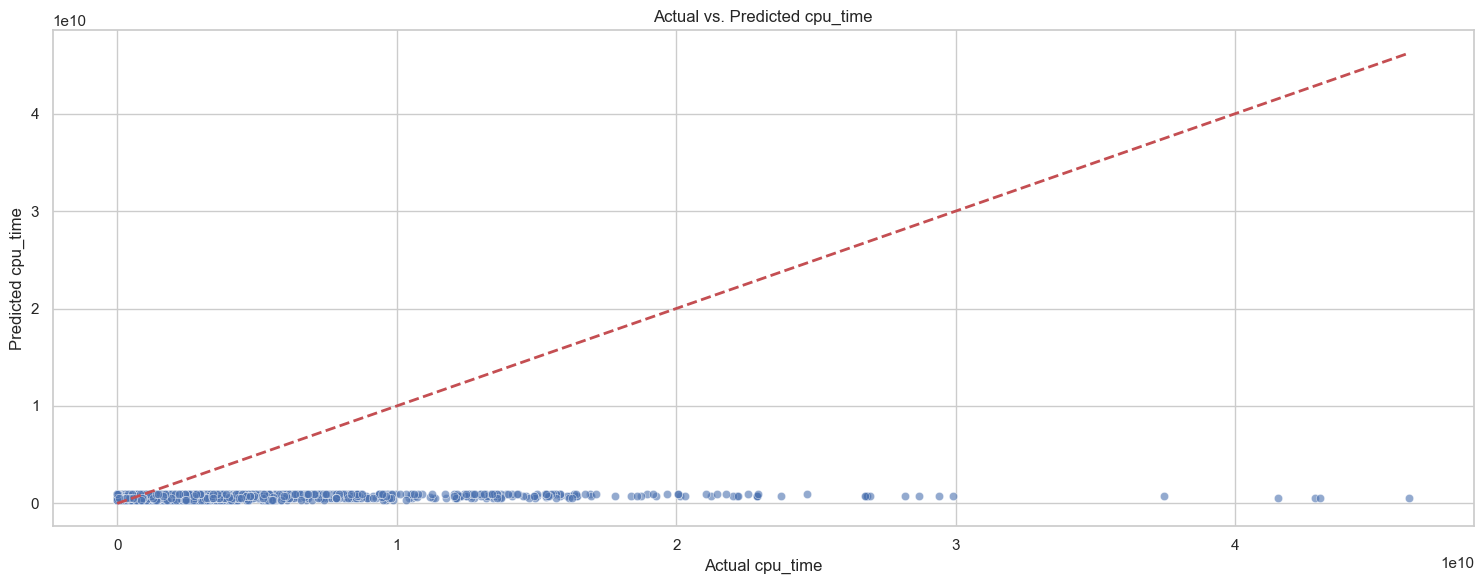

In [22]:
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))

sns.scatterplot(x=y_val, y=predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2) # Diagonal line
ax1.set_title(f'Actual vs. Predicted {target}')
ax1.set_xlabel(f'Actual {target}')
ax1.set_ylabel(f'Predicted {target}')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [ ]:

param_grid = {
    'max_depth': [None, 10, 15, 20, 25, 30, 50],
    'learning_rate': [0.01, 0.1, 0.2, 0.25, 0.3],
    'max_iter': [50, 100, 200, 300, 400],
}

grid_search = GridSearchCV(HistGradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best R-squared from Grid Search: {grid_search.best_score_:.4f}")
print(grid_search.best_params_)

# Best R-squared from Grid Search: 0.3627
# {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 100}

## Predicting Testing Set

Interestingly, the r_squared on the final test data is better than the validation set.

In [23]:
test_predictions = ensemble.predict(X_test)

test_mse = mean_squared_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)
print(f"Mean Squared Error: {test_mse:.4f}")
print(f"R-squared Score: {test_r2:.2f}")

Mean Squared Error: 3184527245579506688.0000
R-squared Score: 0.02


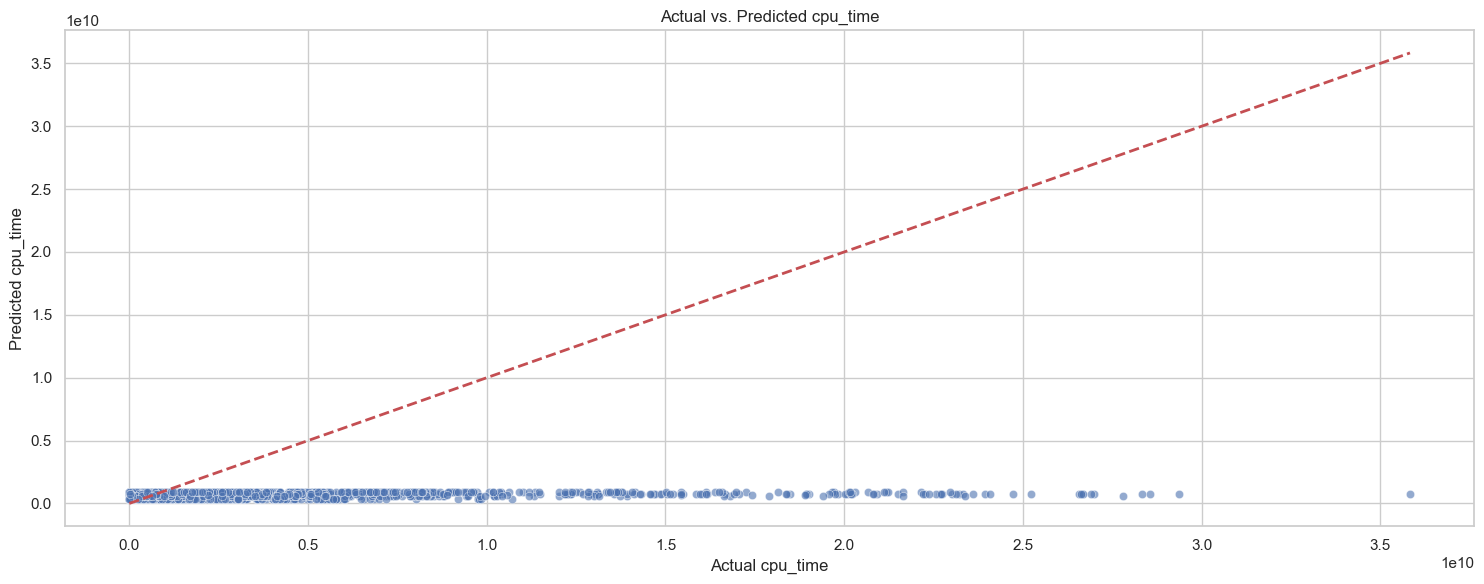

In [24]:
fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))

sns.scatterplot(x=y_test, y=test_predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
ax1.set_title(f'Actual vs. Predicted {target}')
ax1.set_xlabel(f'Actual {target}')
ax1.set_ylabel(f'Predicted {target}')

plt.tight_layout()
plt.show()

In [ ]:
# Possible next steps ---
# TODO: 4. maybe try break up "ocean" exp_component --- even further... 
# TODO: 6. More Hyper-parameter tuning
# TODO: 8. Try removing log and going again... maybe standarization for everything rather than log....
# TODO: 9. Try adding back in group data... just to see...
# TODO: 10. Try limiting features based on all "exp_component" or all another group of features rather than single highest correlated values.
# TODO: 11. I can get more data --- query more... can ask ian for db support (note: querying after 3 weeks is good, possibly use "before=-21" in get_jobs in epmt_query.py) --- double-check please
# TODO: 12. Try out epmt 5.0.0!!!!! (higher priority)
